  IND AS 117 LIFE INSURANCE MODEL — STARTING

✔ SECTION 1: IALM 2012-14 loaded
   Age 25 male qx : 0.000931
   Age 35 male qx : 0.001202
   Age 45 male qx : 0.002579
   Age 55 male qx : 0.007513

✔ SECTION 2: RBI G-Sec yield curve ready
    1-yr rate : 6.40%
    5-yr rate : 6.65%
   10-yr rate : 6.53%
   20-yr rate : 6.85%
   30-yr rate : 7.00%

✔ SECTION 3: Actuarial functions ready
   Test — Male, age 35, SA ₹25L, 20yr: ₹5,939 net premium p.a.

✔ SECTION 4: Portfolio simulated
   Policies        : 1000
   Avg entry age   : 40.1 years
   Male            : 69.3%
   Avg SA          : ₹27.7 lakh

✔ SECTION 5: Calculating premiums and BEL..........
   Avg net premium   : ₹    13,040 p.a.
   Avg gross premium : ₹    18,264 p.a.
   Total BEL         : ₹    -1.607 crore
   (negative BEL = profitable book — profit becomes CSM)

✔ SECTION 6: Monte Carlo Risk Adjustment (500 scenarios)
   Progress: 50 100 150 200 250 300 350 400 450 500 
   Mean claims PV   : ₹13.508 crore
   75th percentile  :

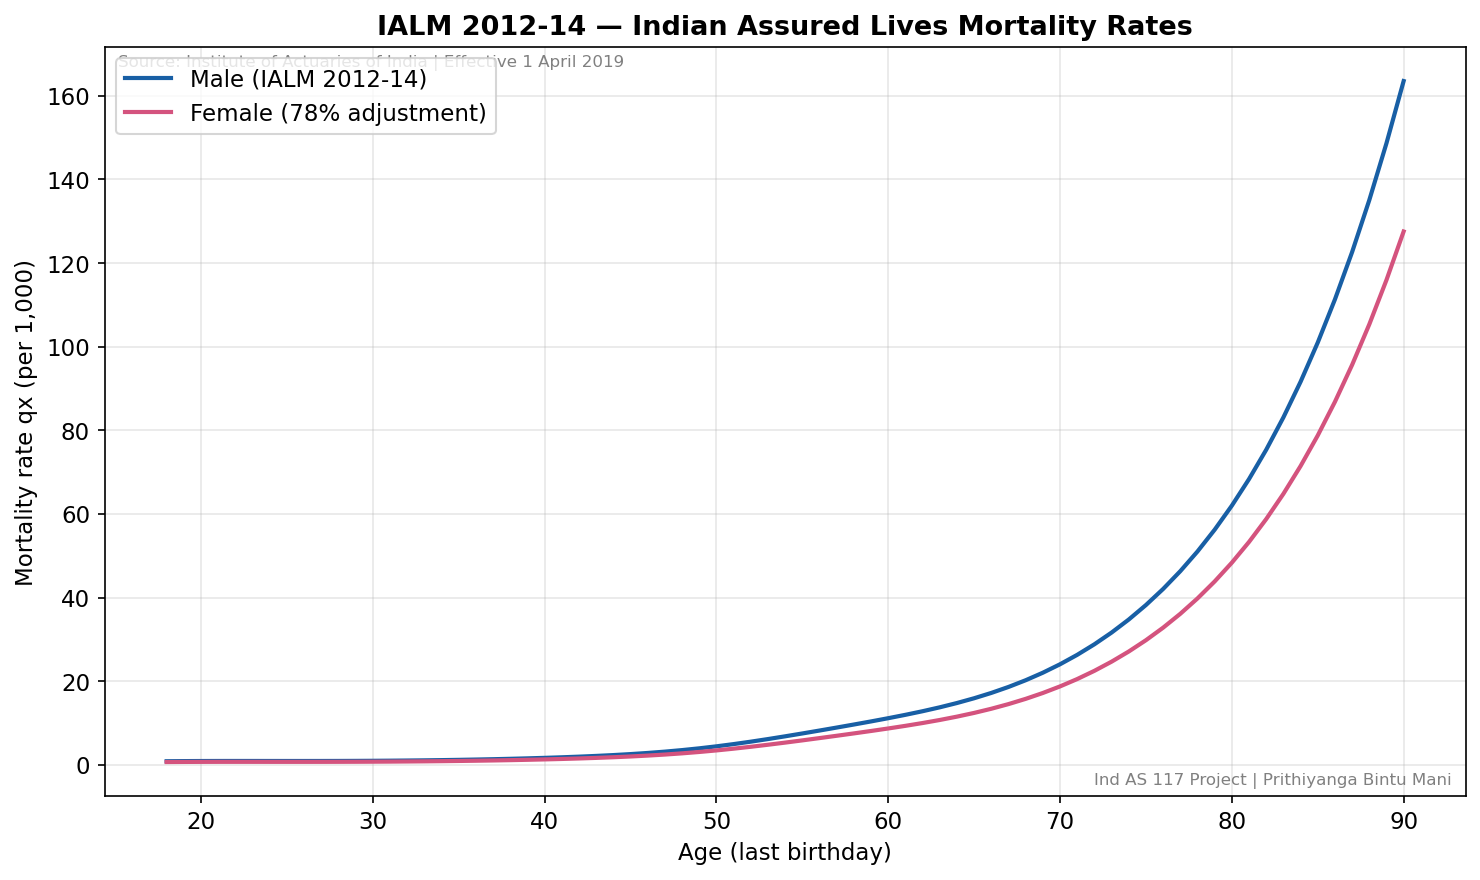

   ✔ Chart 1 saved — IALM Mortality Curve


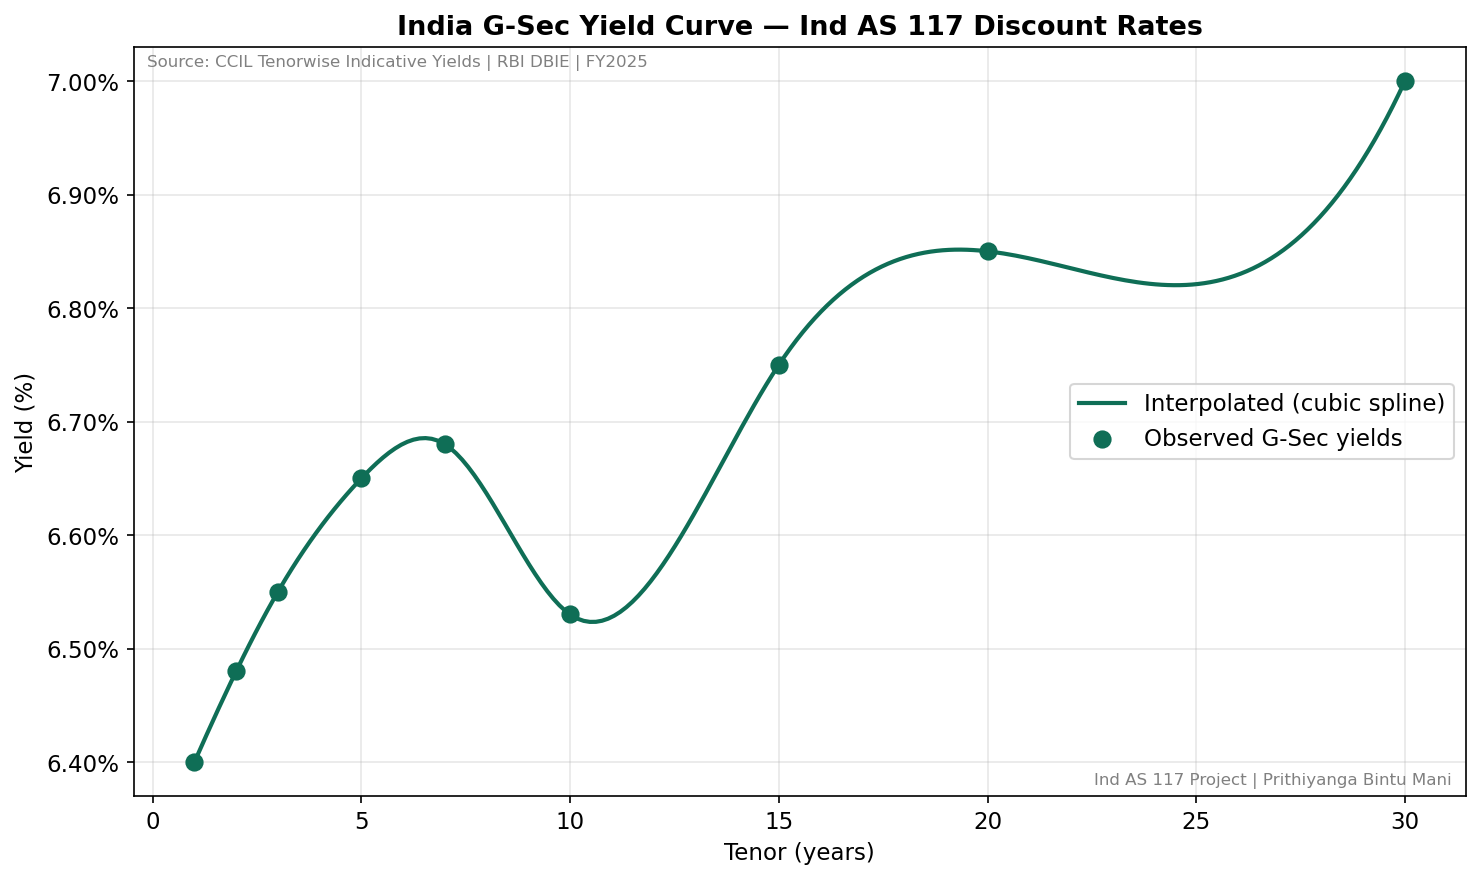

   ✔ Chart 2 saved — G-Sec Yield Curve


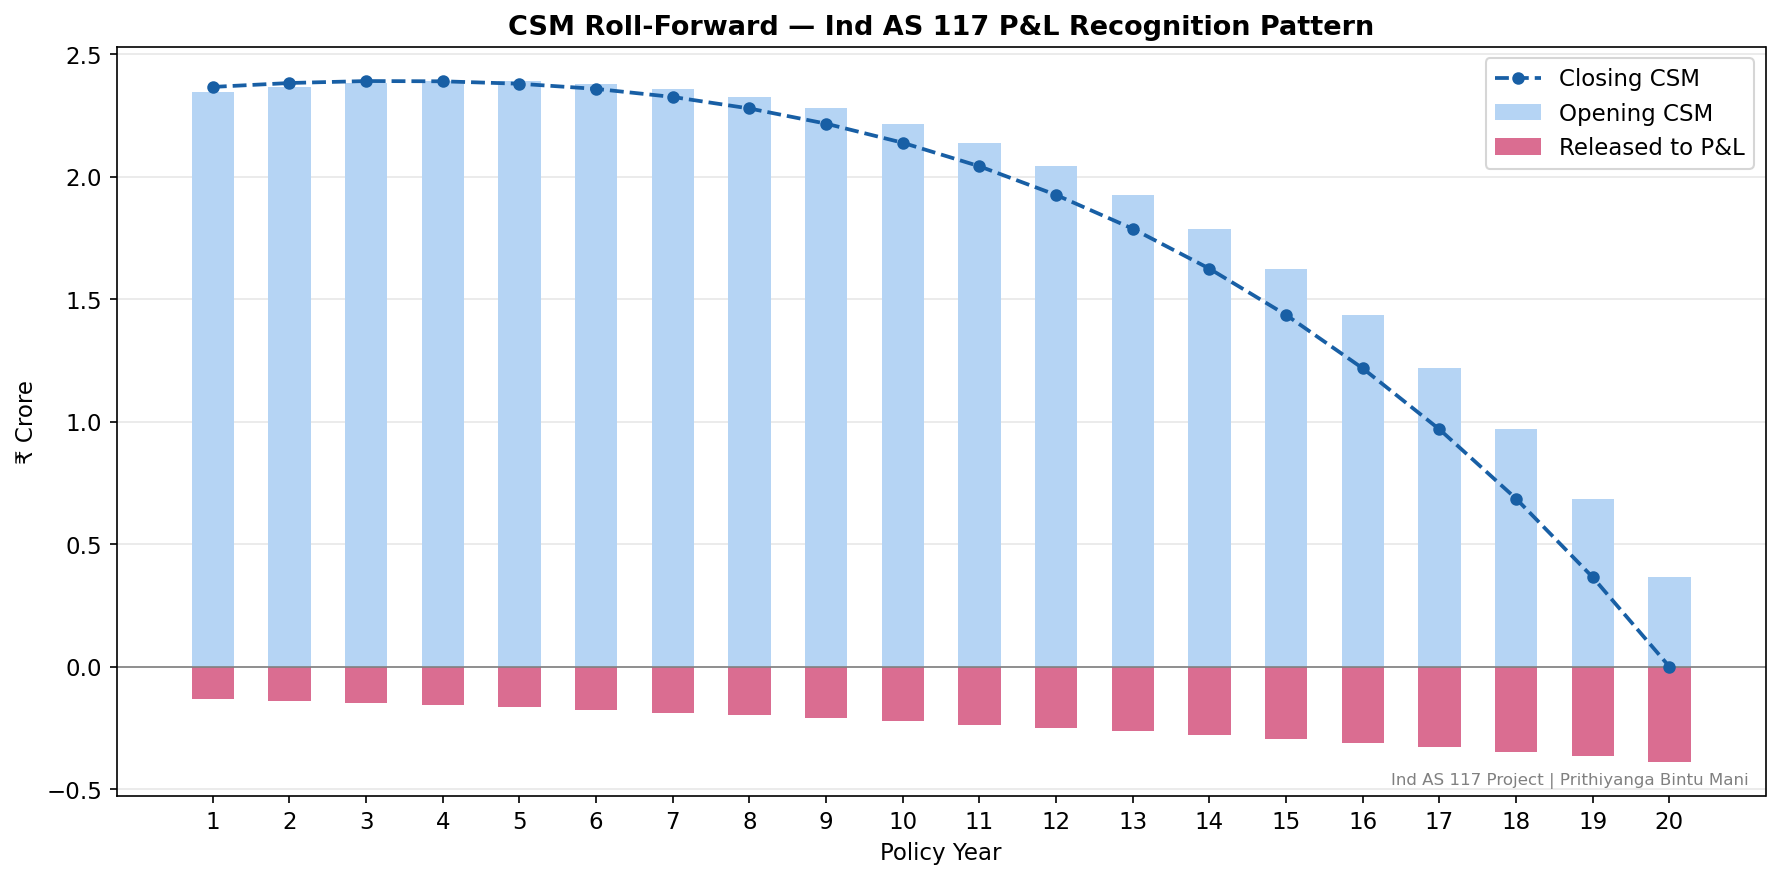

   ✔ Chart 3 saved — CSM Roll-Forward


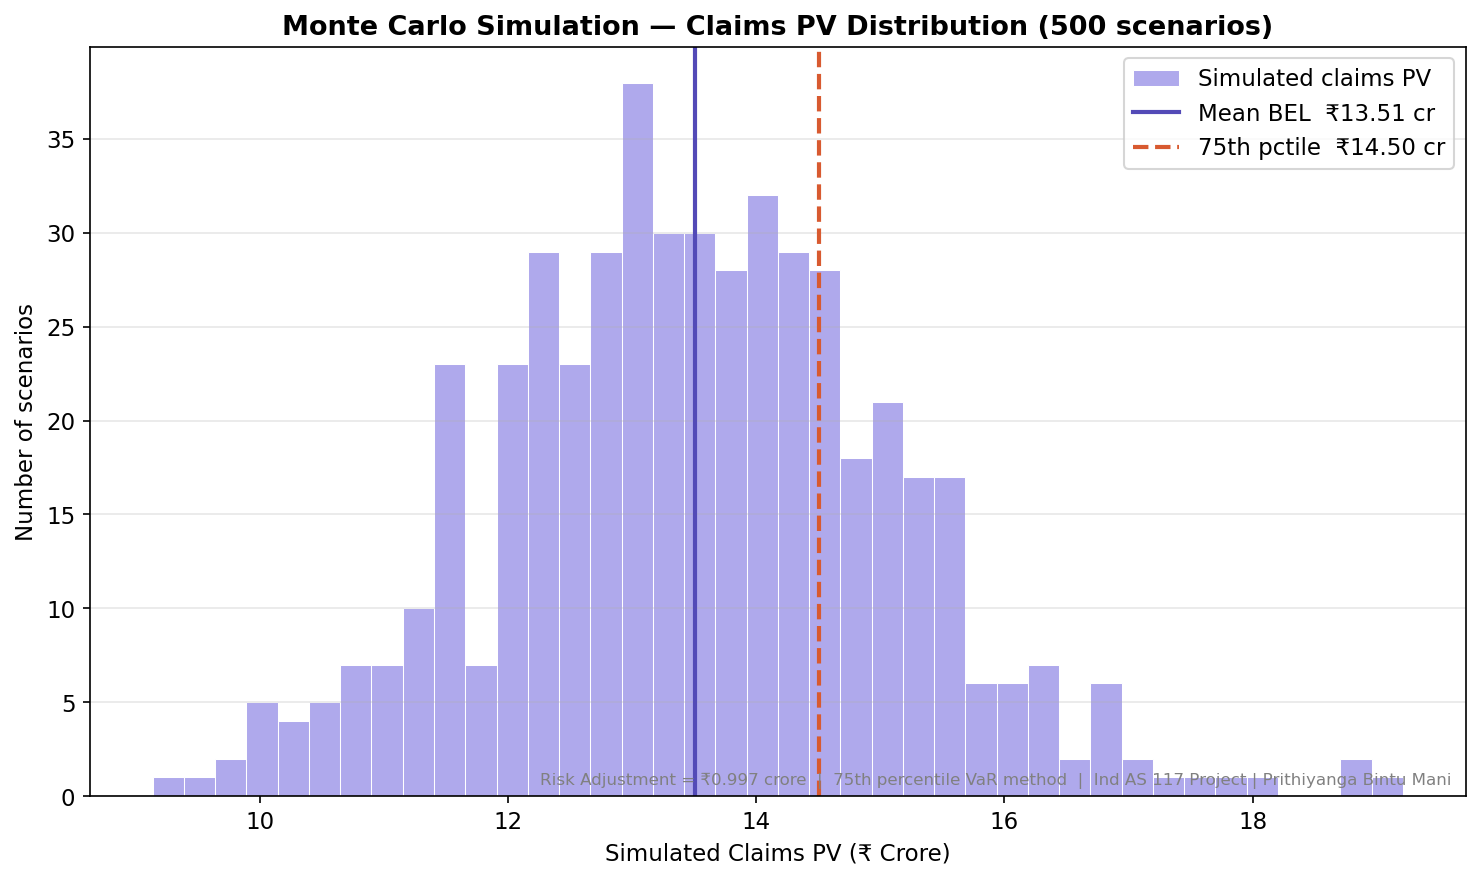

   ✔ Chart 4 saved — Monte Carlo Distribution

✔ SECTION 9: Files saved
   CSM_Rollforward.csv
   Portfolio_Data.csv
   Chart1_IALM_Mortality.png
   Chart2_Yield_Curve.png
   Chart3_CSM_Rollforward.png
   Chart4_MonteCarlo_BEL.png

  PROJECT COMPLETE


In [1]:
# =============================================================================
# IND AS 117 (IFRS 17) — LIFE INSURANCE CSM MODEL
# Indian Market | IALM 2012-14 | RBI G-Sec | IRDAI 2024-25
# Author  : Prithiyanga Bintu Mani
# Language: Python 3.8+
#
# Data Sources:
#   Mortality : IALM 2012-14 — Institute of Actuaries of India
#               https://www.actuariesindia.org/mortality-table
#   Yields    : RBI G-Sec — CCIL / RBI DBIE
#               https://www.ccilindia.com/tenorwise-indicative-yields
#               https://data.rbi.org.in
#   Industry  : IRDAI Annual Report 2024-25
#               https://irdai.gov.in/annual-reports
#
# HOW TO RUN:
#   1. Install libraries once:  pip install numpy matplotlib pandas scipy
#   2. Run:  python IndAS117_Model.py
#   3. All charts saved as PNG in the same folder as this script
#      + summary table saved as CSM_Rollforward.csv
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.interpolate import CubicSpline

# reproducibility
np.random.seed(42)

print("=" * 62)
print("  IND AS 117 LIFE INSURANCE MODEL — STARTING")
print("=" * 62)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: IALM 2012-14 MORTALITY TABLE
# Source : Institute of Actuaries of India (IAI)
# URL    : https://www.actuariesindia.org/mortality-table
# Note   : Exact qx values from the published PDF
#          Male insured lives, medically underwritten at inception
#          Age last birthday | Effective 1 April 2019 (IRDAI regulation)
# ─────────────────────────────────────────────────────────────────────────────

IALM_AGES = list(range(2, 116))   # ages 2 to 115

IALM_QX_MALE = [
    # age:  2         3         4         5         6
    0.000915, 0.000470, 0.000271, 0.000185, 0.000152,
    # age:  7         8         9        10        11
    0.000149, 0.000167, 0.000206, 0.000265, 0.000341,
    # age: 12        13        14        15        16
    0.000429, 0.000522, 0.000614, 0.000698, 0.000770,
    # age: 17        18        19        20        21
    0.000829, 0.000874, 0.000905, 0.000924, 0.000934,
    # age: 22        23        24        25        26
    0.000937, 0.000936, 0.000933, 0.000931, 0.000931,
    # age: 27        28        29        30        31
    0.000934, 0.000942, 0.000956, 0.000977, 0.001005,
    # age: 32        33        34        35        36
    0.001042, 0.001086, 0.001140, 0.001202, 0.001275,
    # age: 37        38        39        40        41
    0.001358, 0.001453, 0.001560, 0.001680, 0.001815,
    # age: 42        43        44        45        46
    0.001969, 0.002144, 0.002345, 0.002579, 0.002851,
    # age: 47        48        49        50        51
    0.003168, 0.003536, 0.003958, 0.004436, 0.004969,
    # age: 52        53        54        55        56
    0.005550, 0.006174, 0.006831, 0.007513, 0.008212,
    # age: 57        58        59        60        61
    0.008925, 0.009651, 0.010393, 0.011162, 0.011969,
    # age: 62        63        64        65        66
    0.012831, 0.013765, 0.014792, 0.015932, 0.017206,
    # age: 67        68        69        70        71
    0.018635, 0.020240, 0.022040, 0.024058, 0.026314,
    # age: 72        73        74        75        76
    0.028832, 0.031638, 0.034757, 0.038221, 0.042061,
    # age: 77        78        79        80        81
    0.046316, 0.051024, 0.056231, 0.061985, 0.068338,
    # age: 82        83        84        85        86
    0.075350, 0.083082, 0.091601, 0.100979, 0.111291,
    # age: 87        88        89        90        91
    0.122616, 0.135037, 0.148639, 0.163507, 0.179726,
    # age: 92        93        94        95        96
    0.197380, 0.216547, 0.237302, 0.259706, 0.283813,
    # age: 97        98        99       100       101
    0.309659, 0.337265, 0.366630, 0.397733, 0.430529,
    # age:102       103       104       105       106
    0.464950, 0.500904, 0.538278, 0.576942, 0.616752,
    # age:107       108       109       110       111
    0.657553, 0.699191, 0.741515, 0.784383, 0.827673,
    # age:112       113       114       115
    0.871285, 0.915145, 0.959214, 1.000000,
]

assert len(IALM_QX_MALE) == len(IALM_AGES), "IALM length mismatch!"

# Female = 78% of male (IRDAI/LIC actuarial practice — LIC Valuation Basis L-42)
IALM_QX_FEMALE = [qx * 0.78 for qx in IALM_QX_MALE]

# Build dictionaries for fast lookup by age
qx_male   = dict(zip(IALM_AGES, IALM_QX_MALE))
qx_female = dict(zip(IALM_AGES, IALM_QX_FEMALE))

def get_qx(age, gender):
    """Return qx for given age and gender from IALM 2012-14."""
    age = min(int(age), 115)
    return qx_male.get(age, 1.0) if gender == 'M' else qx_female.get(age, 1.0)

print("\n✔ SECTION 1: IALM 2012-14 loaded")
print(f"   Age 25 male qx : {get_qx(25,'M'):.6f}")
print(f"   Age 35 male qx : {get_qx(35,'M'):.6f}")
print(f"   Age 45 male qx : {get_qx(45,'M'):.6f}")
print(f"   Age 55 male qx : {get_qx(55,'M'):.6f}")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: RBI G-SEC YIELD CURVE
# Source : CCIL Tenorwise Indicative Yields (live data)
# URL    : https://www.ccilindia.com/tenorwise-indicative-yields
#          https://data.rbi.org.in  (historical download)
# Note   : Under Ind AS 117, discount rates must reflect
#          current market rates at each reporting date (Para 36)
# ─────────────────────────────────────────────────────────────────────────────

GSEC_TENORS = np.array([1,  2,    3,    5,    7,    10,   15,   20,   30],  dtype=float)
GSEC_YIELDS = np.array([0.0640, 0.0648, 0.0655, 0.0665, 0.0668,
                        0.0653, 0.0675, 0.0685, 0.0700])

# Cubic spline interpolation — smooth curve through all tenor points
yield_spline = CubicSpline(GSEC_TENORS, GSEC_YIELDS)

def get_rate(t):
    """Interpolated G-Sec yield for tenor t (clamped to 1–30 yr range)."""
    t = max(min(float(t), 30.0), 1.0)
    return float(yield_spline(t))

def disc(t):
    """Spot discount factor: v(t) = 1 / (1 + r(t))^t."""
    return 1.0 / (1.0 + get_rate(t)) ** t

print("\n✔ SECTION 2: RBI G-Sec yield curve ready")
for tenor in [1, 5, 10, 20, 30]:
    print(f"   {tenor:2d}-yr rate : {get_rate(tenor)*100:.2f}%")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: ACTUARIAL HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def get_tpx(entry_age, gender, term):
    """
    Survival probability vector.
    tpx[0] = 1.0  (alive at policy start)
    tpx[t] = probability of surviving t full years from entry
    """
    tpx    = [0.0] * (term + 1)
    tpx[0] = 1.0
    for t in range(1, term + 1):
        qx     = get_qx(entry_age + t - 1, gender)
        tpx[t] = tpx[t - 1] * (1.0 - qx)
    return tpx

def epv_death_benefit(entry_age, gender, sa, term):
    """EPV of death benefit (paid at mid-year of death)."""
    tpx = get_tpx(entry_age, gender, term)
    return sum(
        tpx[t] * get_qx(entry_age + t - 1, gender) * sa * disc(t - 0.5)
        for t in range(1, term + 1)
    )

def epv_annuity_due(entry_age, gender, term):
    """EPV of annuity-due (premium paid at start of each year alive)."""
    tpx = get_tpx(entry_age, gender, term)
    return sum(tpx[t] * disc(t - 1) for t in range(1, term + 1))

def calc_net_premium(entry_age, gender, sa, term):
    """Net annual premium by equivalence principle (no loadings)."""
    return epv_death_benefit(entry_age, gender, sa, term) / \
           epv_annuity_due(entry_age, gender, term)

print("\n✔ SECTION 3: Actuarial functions ready")
test = calc_net_premium(35, 'M', 2_500_000, 20)
print(f"   Test — Male, age 35, SA ₹25L, 20yr: ₹{test:,.0f} net premium p.a.")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4: SIMULATE PORTFOLIO (1,000 POLICIES)
# Calibrated to IRDAI Annual Report 2024-25
# Source : https://irdai.gov.in/annual-reports
# ─────────────────────────────────────────────────────────────────────────────

N   = 1000   # number of policies
TRM = 20     # policy term (years)

# Pricing basis (IRDAI Annual Report 2024-25)
EXPENSE_RATIO   = 0.156   # 15.6% management expense ratio
COMMISSION_RATE = 0.050   # 5.0% agent commission
PROFIT_MARGIN   = 0.080   # 8.0% profit loading → creates positive CSM

rng = np.random.default_rng(42)

ages    = rng.integers(25, 56, size=N)                              # 25–55
genders = rng.choice(['M', 'F'], size=N, p=[0.70, 0.30])           # 70/30 split
sa_lakh = np.clip(np.round(rng.lognormal(np.log(25), 0.55, N)), 5, 100)
sa_inr  = sa_lakh * 100_000                                         # ₹ rupees

print("\n✔ SECTION 4: Portfolio simulated")
print(f"   Policies        : {N}")
print(f"   Avg entry age   : {ages.mean():.1f} years")
print(f"   Male            : {100*(genders=='M').mean():.1f}%")
print(f"   Avg SA          : ₹{sa_inr.mean()/1e5:.1f} lakh")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: PREMIUMS & BEST ESTIMATE LIABILITY (BEL)
#
# Gross premium = Net premium / (1 - expense ratio - commission - profit margin)
# BEL = EPV(future claims + future expenses) - EPV(future gross premiums)
#
# Under Ind AS 117 GMM (General Measurement Model / Building Block Approach):
#   • Negative BEL = insurer expects to profit = profitable book
#   • The negative FCF amount becomes the CSM (unearned profit)
# ─────────────────────────────────────────────────────────────────────────────

print("\n✔ SECTION 5: Calculating premiums and BEL", end="", flush=True)

net_prems   = []
gross_prems = []
bels        = []

for i in range(N):
    if (i + 1) % 100 == 0:
        print(".", end="", flush=True)

    a = int(ages[i])
    g = genders[i]
    s = float(sa_inr[i])
    t = TRM

    tpx = get_tpx(a, g, t)

    # Net premium (pure actuarial cost)
    np_val = calc_net_premium(a, g, s, t)

    # Gross premium (what policyholder pays — includes expenses + profit)
    gp = np_val / (1 - EXPENSE_RATIO - COMMISSION_RATE - PROFIT_MARGIN)

    # BEL = EPV(outflows) - EPV(inflows)
    epv_out = sum(
        tpx[yr] * get_qx(a + yr - 1, g) * s * disc(yr - 0.5)        # claims
        + tpx[yr] * gp * (EXPENSE_RATIO + COMMISSION_RATE) * disc(yr - 1)  # expenses
        for yr in range(1, t + 1)
    )
    epv_in = sum(tpx[yr] * gp * disc(yr - 1) for yr in range(1, t + 1))

    net_prems.append(np_val)
    gross_prems.append(gp)
    bels.append(epv_out - epv_in)

print()

total_bel    = sum(bels)
total_gp_yr1 = sum(gross_prems)

print(f"   Avg net premium   : ₹{np.mean(net_prems):>10,.0f} p.a.")
print(f"   Avg gross premium : ₹{np.mean(gross_prems):>10,.0f} p.a.")
print(f"   Total BEL         : ₹{total_bel/1e7:>10.3f} crore")
print("   (negative BEL = profitable book — profit becomes CSM)")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: RISK ADJUSTMENT — MONTE CARLO (500 SCENARIOS)
#
# Under Ind AS 117, Risk Adjustment = compensation for non-financial risk
# Method : 75th percentile VaR (most common in Indian actuarial practice)
# Logic  : Simulate random deaths using np.random.binomial() per policy per year
#          Build distribution of total claims PV across 500 scenarios
#          RA = 75th percentile − Mean
# ─────────────────────────────────────────────────────────────────────────────

N_SIM = 500
sim_claims = np.zeros(N_SIM)

print(f"\n✔ SECTION 6: Monte Carlo Risk Adjustment ({N_SIM} scenarios)")
print("   Progress: ", end="", flush=True)

for sim in range(N_SIM):
    if (sim + 1) % 50 == 0:
        print(f"{sim+1}", end=" ", flush=True)

    total_pv = 0.0

    for i in range(N):
        a = int(ages[i])
        g = genders[i]
        s = float(sa_inr[i])
        t = TRM
        tpx = get_tpx(a, g, t)

        for yr in range(1, t + 1):
            qx    = get_qx(a + yr - 1, g)
            # binomial draw: did this person die in year yr?
            death = rng.binomial(1, tpx[yr] * qx)
            if death == 1:
                total_pv += s * disc(yr - 0.5)
                break   # policy terminates on death

    sim_claims[sim] = total_pv

mean_claims = float(np.mean(sim_claims))
p75_claims  = float(np.percentile(sim_claims, 75))
ra          = p75_claims - mean_claims

print()
print(f"   Mean claims PV   : ₹{mean_claims/1e7:.3f} crore")
print(f"   75th percentile  : ₹{p75_claims/1e7:.3f} crore")
print(f"   Risk Adjustment  : ₹{ra/1e7:.3f} crore")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: IND AS 117 BALANCE SHEET + CSM ROLL-FORWARD
#
# Insurance Contract Liability = BEL + RA + CSM
# CSM = unearned profit locked in at inception, released to P&L as
#       service is delivered each year (Ind AS 117 Para 44)
#
# CSM Roll-Forward each year:
#   Opening CSM
#   + Interest accretion  (locked-in rate at inception = 10-yr G-Sec)
#   - CSM released to P&L (proportional to coverage units delivered)
#   = Closing CSM
# CSM reaches zero at end of coverage period (all profit recognised)
# ─────────────────────────────────────────────────────────────────────────────

acq_cost = total_gp_yr1 * COMMISSION_RATE
fcf      = total_bel + ra + acq_cost - total_gp_yr1
csm_0    = -fcf

if csm_0 < 0:
    print(f"\n⚠ Onerous contract — loss recognised: ₹{abs(csm_0)/1e7:.3f} crore")
    csm_0 = 0.0

# Locked-in accretion rate = 10-yr G-Sec yield at inception
accretion_rate = get_rate(10)

# Coverage units per year = expected alive policyholders
cu = []
for yr in range(1, TRM + 1):
    alive = sum(
        get_tpx(int(ages[i]), genders[i], TRM)[min(yr + 1, TRM)]
        for i in range(N)
    )
    cu.append(alive)

# Build roll-forward table
rf_rows = []
csm_now = csm_0
for yr in range(TRM):
    interest = csm_now * accretion_rate
    rem_cu   = sum(cu[yr:])
    rel_pct  = cu[yr] / rem_cu if rem_cu > 0 else 0.0
    released = (csm_now + interest) * rel_pct
    closing  = csm_now + interest - released

    rf_rows.append({
        "Year"    : yr + 1,
        "CU"      : round(cu[yr], 1),
        "Opening" : round(csm_now  / 1e7, 3),
        "Interest": round(interest / 1e7, 3),
        "Released": round(released / 1e7, 3),
        "Closing" : round(closing  / 1e7, 3),
    })
    csm_now = closing

rf = pd.DataFrame(rf_rows)

# ── Print full summary ────────────────────────────────────────────────────────
print("\n")
print("=" * 62)
print("  IND AS 117 — INSURANCE CONTRACT LIABILITY AT INCEPTION")
print("=" * 62)
print(f"  Policies              : {N} Indian term life policies")
print(f"  Term                  : {TRM} years")
print(f"  Mortality basis       : IALM 2012-14 (IAI)")
print(f"  Discount curve        : RBI G-Sec — CCIL/DBIE FY2025")
print(f"  Expense ratio         : {EXPENSE_RATIO*100:.1f}%  (IRDAI AR 2024-25)")
print(f"  Profit margin loading : {PROFIT_MARGIN*100:.1f}%")
print("-" * 62)
print(f"  Best Estimate Liability (BEL)     : ₹{total_bel/1e7:>8.3f} crore")
print(f"  Risk Adjustment (RA) [75th pctile]: ₹{ra/1e7:>8.3f} crore")
print(f"  Contractual Service Margin (CSM)  : ₹{csm_0/1e7:>8.3f} crore")
print("-" * 62)
print(f"  Total Insurance Contract Liability: ₹{(total_bel+ra+csm_0)/1e7:>8.3f} crore")
print("=" * 62)

print(f"\n  CSM ROLL-FORWARD (₹ crore) — Ind AS 117 Para 44")
print(f"  Locked-in accretion rate : {accretion_rate*100:.2f}% (10-yr G-Sec at inception)")
print(f"  {'Year':<6} {'Opening':>9} {'Interest':>9} {'Released':>9} {'Closing':>9}")
print("  " + "─" * 42)
for row in rf_rows:
    print(f"  {row['Year']:<6} {row['Opening']:>9.3f} {row['Interest']:>9.3f} "
          f"{row['Released']:>9.3f} {row['Closing']:>9.3f}")
print("=" * 62)


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: CHARTS (4 charts saved as PNG)
# ─────────────────────────────────────────────────────────────────────────────

print("\n✔ SECTION 8: Generating charts...")
CAPTION = "Ind AS 117 Project | Prithiyanga Bintu Mani"
plt.rcParams.update({"font.size": 11, "figure.dpi": 150})

# ── Chart 1: IALM 2012-14 Mortality Curve ─────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 6))

plot_ages = list(range(18, 91))
male_qx   = [get_qx(a, 'M') * 1000 for a in plot_ages]
female_qx = [get_qx(a, 'F') * 1000 for a in plot_ages]

ax1.plot(plot_ages, male_qx,   color="#185FA5", linewidth=2.0,
         label="Male (IALM 2012-14)")
ax1.plot(plot_ages, female_qx, color="#D4537E", linewidth=2.0,
         label="Female (78% adjustment)")

ax1.set_title("IALM 2012-14 — Indian Assured Lives Mortality Rates",
              fontsize=13, fontweight="bold")
ax1.set_xlabel("Age (last birthday)")
ax1.set_ylabel("Mortality rate qx (per 1,000)")
ax1.legend(loc="upper left")
ax1.text(0.99, 0.01, CAPTION, transform=ax1.transAxes,
         ha="right", va="bottom", fontsize=8, color="grey")
ax1.text(0.01, 0.99, "Source: Institute of Actuaries of India | Effective 1 April 2019",
         transform=ax1.transAxes, ha="left", va="top", fontsize=8, color="grey")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Chart1_IALM_Mortality.png", dpi=300)
plt.show()
print("   ✔ Chart 1 saved — IALM Mortality Curve")

# ── Chart 2: RBI G-Sec Yield Curve ────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 6))

tenors_plot = np.linspace(1, 30, 200)
yields_plot = [get_rate(t) * 100 for t in tenors_plot]

ax2.plot(tenors_plot, yields_plot, color="#0F6E56", linewidth=2.0,
         label="Interpolated (cubic spline)")
ax2.scatter(GSEC_TENORS, GSEC_YIELDS * 100, color="#0F6E56",
            s=60, zorder=5, label="Observed G-Sec yields")

ax2.set_title("India G-Sec Yield Curve — Ind AS 117 Discount Rates",
              fontsize=13, fontweight="bold")
ax2.set_xlabel("Tenor (years)")
ax2.set_ylabel("Yield (%)")
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))
ax2.legend()
ax2.text(0.99, 0.01, CAPTION, transform=ax2.transAxes,
         ha="right", va="bottom", fontsize=8, color="grey")
ax2.text(0.01, 0.99, "Source: CCIL Tenorwise Indicative Yields | RBI DBIE | FY2025",
         transform=ax2.transAxes, ha="left", va="top", fontsize=8, color="grey")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("Chart2_Yield_Curve.png", dpi=300)
plt.show()
print("   ✔ Chart 2 saved — G-Sec Yield Curve")

# ── Chart 3: CSM Roll-Forward Waterfall ───────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(12, 6))

years     = rf["Year"].tolist()
opening   = rf["Opening"].tolist()
released  = rf["Released"].tolist()
closing   = rf["Closing"].tolist()
interest  = rf["Interest"].tolist()

x = np.arange(1, TRM + 1)
w = 0.55

bars_open = ax3.bar(x, opening,  width=w, color="#B5D4F4", label="Opening CSM",      zorder=2)
bars_rel  = ax3.bar(x, [-r for r in released], width=w, color="#D4537E",
                    alpha=0.85, label="Released to P&L", zorder=2)
ax3.plot(x, closing, color="#185FA5", linewidth=1.8,
         linestyle="--", marker="o", markersize=5, label="Closing CSM", zorder=3)
ax3.axhline(0, color="grey", linewidth=0.8)

ax3.set_title("CSM Roll-Forward — Ind AS 117 P&L Recognition Pattern",
              fontsize=13, fontweight="bold")
ax3.set_xlabel("Policy Year")
ax3.set_ylabel("₹ Crore")
ax3.set_xticks(x)
ax3.legend(loc="upper right")
ax3.text(0.99, 0.01, CAPTION, transform=ax3.transAxes,
         ha="right", va="bottom", fontsize=8, color="grey")
ax3.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("Chart3_CSM_Rollforward.png", dpi=300)
plt.show()
print("   ✔ Chart 3 saved — CSM Roll-Forward")

# ── Chart 4: Monte Carlo BEL Distribution ─────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(10, 6))

claims_crore = sim_claims / 1e7

ax4.hist(claims_crore, bins=40, color="#AFA9EC", edgecolor="white",
         linewidth=0.5, label="Simulated claims PV")
ax4.axvline(mean_claims / 1e7, color="#534AB7", linewidth=2.0,
            label=f"Mean BEL  ₹{mean_claims/1e7:.2f} cr")
ax4.axvline(p75_claims  / 1e7, color="#D85A30", linewidth=2.0,
            linestyle="--", label=f"75th pctile  ₹{p75_claims/1e7:.2f} cr")

ax4.set_title("Monte Carlo Simulation — Claims PV Distribution (500 scenarios)",
              fontsize=13, fontweight="bold")
ax4.set_xlabel("Simulated Claims PV (₹ Crore)")
ax4.set_ylabel("Number of scenarios")
ax4.legend()
ax4.text(0.99, 0.01,
         f"Risk Adjustment = ₹{ra/1e7:.3f} crore  |  75th percentile VaR method  |  {CAPTION}",
         transform=ax4.transAxes, ha="right", va="bottom", fontsize=8, color="grey")
ax4.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("Chart4_MonteCarlo_BEL.png", dpi=300)
plt.show()
print("   ✔ Chart 4 saved — Monte Carlo Distribution")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9: SAVE TABLES TO CSV
# ─────────────────────────────────────────────────────────────────────────────

rf.to_csv("CSM_Rollforward.csv", index=False)

portfolio_df = pd.DataFrame({
    "Policy_ID"      : range(1, N + 1),
    "Entry_Age"      : ages,
    "Gender"         : genders,
    "SA_INR"         : sa_inr.astype(int),
    "SA_Lakh"        : sa_lakh.astype(int),
    "Net_Premium"    : [round(x, 0) for x in net_prems],
    "Gross_Premium"  : [round(x, 0) for x in gross_prems],
    "BEL"            : [round(x, 0) for x in bels],
})
portfolio_df.to_csv("Portfolio_Data.csv", index=False)

print("\n✔ SECTION 9: Files saved")
print("   CSM_Rollforward.csv")
print("   Portfolio_Data.csv")
print("   Chart1_IALM_Mortality.png")
print("   Chart2_Yield_Curve.png")
print("   Chart3_CSM_Rollforward.png")
print("   Chart4_MonteCarlo_BEL.png")

print("\n" + "=" * 62)
print("  PROJECT COMPLETE")
print("=" * 62)